In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
import joblib

c:\Users\Amir sohail\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
df = pd.read_csv("speech_recognition_transcription.csv")
df.head()

,audio_id,file_name,duration_sec,sample_rate_hz,mfcc_mean,mel_spectrogram_mean,log_mel_spectrogram_mean,pitch_hz,energy,rms_energy,zero_crossing_rate,delta_features_mean,delta_delta_features_mean,transcript_text
0,ASR_00001,audio_sample_00001.wav,22.71,8000,-101.559,151.356,-7.479,166.49,0.3602,0.2399,0.1244,-2.925,-1.551,Participants discussed evaluation metrics befo...
1,ASR_00002,audio_sample_00002.wav,9.01,22050,-78.185,92.299,-6.230,205.48,0.4867,0.4312,0.0818,3.292,-0.948,The discussion scheduled the final roadmap to ...
2,ASR_00003,audio_sample_00003.wav,28.19,44100,-90.366,215.363,-1.969,75.00,0.3829,0.2852,0.0316,1.473,-2.634,The discussion presented the final roadmap bef...
3,ASR_00004,audio_sample_00004.wav,16.63,22050,-77.621,173.317,-7.079,145.05,0.5582,0.4695,0.1090,0.972,0.198,"In this client call, the speaker explained noi..."
4,ASR_00005,audio_sample_00005.wav,24.19,8000,-40.735,218.823,-4.622,169.27,0.5205,0.3769,0.0827,1.119,-0.605,The discussion confirmed customer feedback for...


In [3]:
df.columns

Index(['audio_id', 'file_name', 'duration_sec', 'sample_rate_hz', 'mfcc_mean',
       'mel_spectrogram_mean', 'log_mel_spectrogram_mean', 'pitch_hz',
       'energy', 'rms_energy', 'zero_crossing_rate', 'delta_features_mean',
       'delta_delta_features_mean', 'transcript_text'],
      dtype='object')

In [4]:
df.shape

(2500, 14)

In [5]:
df.drop(columns=["audio_id","file_name","sample_rate_hz"], inplace=True)
df.head()

,duration_sec,mfcc_mean,mel_spectrogram_mean,log_mel_spectrogram_mean,pitch_hz,energy,rms_energy,zero_crossing_rate,delta_features_mean,delta_delta_features_mean,transcript_text
0,22.71,-101.559,151.356,-7.479,166.49,0.3602,0.2399,0.1244,-2.925,-1.551,Participants discussed evaluation metrics befo...
1,9.01,-78.185,92.299,-6.230,205.48,0.4867,0.4312,0.0818,3.292,-0.948,The discussion scheduled the final roadmap to ...
2,28.19,-90.366,215.363,-1.969,75.00,0.3829,0.2852,0.0316,1.473,-2.634,The discussion presented the final roadmap bef...
3,16.63,-77.621,173.317,-7.079,145.05,0.5582,0.4695,0.1090,0.972,0.198,"In this client call, the speaker explained noi..."
4,24.19,-40.735,218.823,-4.622,169.27,0.5205,0.3769,0.0827,1.119,-0.605,The discussion confirmed customer feedback for...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   duration_sec               2500 non-null   float64
 1   mfcc_mean                  2500 non-null   float64
 2   mel_spectrogram_mean       2500 non-null   float64
 3   log_mel_spectrogram_mean   2500 non-null   float64
 4   pitch_hz                   2500 non-null   float64
 5   energy                     2500 non-null   float64
 6   rms_energy                 2500 non-null   float64
 7   zero_crossing_rate         2500 non-null   float64
 8   delta_features_mean        2500 non-null   float64
 9   delta_delta_features_mean  2500 non-null   float64
 10  transcript_text            2500 non-null   object 
dtypes: float64(10), object(1)
memory usage: 215.0+ KB


In [7]:
df.describe()

,duration_sec,mfcc_mean,mel_spectrogram_mean,log_mel_spectrogram_mean,pitch_hz,energy,rms_energy,zero_crossing_rate,delta_features_mean,delta_delta_features_mean
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,18.001920,-108.505929,128.864826,-2.770357,169.084856,0.479298,0.378528,0.084518,0.004078,-0.032416
std,9.574318,44.425502,68.191242,2.906632,38.060586,0.162636,0.136767,0.029420,2.052597,1.651161
min,1.830000,-184.938000,12.061000,-7.799000,75.000000,0.020000,0.014200,0.005000,-3.599000,-2.899000
25%,9.555000,-145.789000,69.197750,-5.227250,142.180000,0.369375,0.283550,0.065675,-1.786500,-1.387250
50%,18.105000,-109.175500,127.835000,-2.890500,169.395000,0.482250,0.372200,0.084900,0.011500,-0.047000
75%,26.262500,-70.350000,186.726500,-0.131750,196.267500,0.590075,0.470800,0.104600,1.758250,1.370000
max,34.480000,-32.083000,247.976000,2.293000,297.080000,0.980000,0.850000,0.181800,3.600000,2.897000


In [8]:
df.isnull().sum()

duration_sec                 0
mfcc_mean                    0
mel_spectrogram_mean         0
log_mel_spectrogram_mean     0
pitch_hz                     0
energy                       0
rms_energy                   0
zero_crossing_rate           0
delta_features_mean          0
delta_delta_features_mean    0
transcript_text              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
pitch_min = df['pitch_hz'].min()
pitch_max = df['pitch_hz'].max()
df['pitch_norm'] = (df['pitch_hz'] - pitch_min) / (pitch_max - pitch_min)

# Low Energy = Patient is weak/critical
energy_min = df['energy'].min()
energy_max = df['energy'].max()
df['energy_norm'] = 1.0 - ((df['energy'] - energy_min) / (energy_max - energy_min))


# 2. TEXT NLP KEYWORD MATCHING ENGINE
# Medical emergency ke crucial words ki dictionary list
emergency_keywords = [
    'pain', 'chest', 'breathing', 'breath', 'emergency', 'blood', 
    'accident', 'severe', 'heart', 'choking', 'stroke', 'injury'
]

def calculate_text_score(text):
    text_clean = str(text).lower()
    # Check karenge ki kitne emergency keywords match ho rahe hain
    match_count = sum(1 for word in emergency_keywords if word in text_clean)
    
    # Agar 1 ya 1 se zyada words hain toh full weight (1), nahi toh 0
    return 1.0 if match_count > 0 else 0.0

# Keyword matching function ko pooray text column par chalao
df['text_score'] = df['transcript_text'].apply(calculate_text_score)


# 3. FINAL TARGET BLENDING (Weighted Formula)
# Text ko 50% weight, Voice Pitch ko 25%, aur Voice Weakness/Energy ko 25% weight diya
df['urgency_score'] = (df['text_score'] * 0.50) + (df['pitch_norm'] * 0.25) + (df['energy_norm'] * 0.25)


# 4. TEMPORARY COLUMNS KI SAFAI
# Jin intermediate columns se math calculate kiya, unhe drop kar dete hain
df = df.drop(columns=['pitch_norm', 'energy_norm', 'text_score'])

print("🎯 Target Column 'urgency_score' successfully created!")
print(df[['transcript_text', 'pitch_hz', 'energy', 'urgency_score']].head())

🎯 Target Column 'urgency_score' successfully created!
                                     transcript_text  pitch_hz  energy  \
0  Participants discussed evaluation metrics befo...    166.49  0.3602   
1  The discussion scheduled the final roadmap to ...    205.48  0.4867   
2  The discussion presented the final roadmap bef...     75.00  0.3829   
3  In this client call, the speaker explained noi...    145.05  0.5582   
4  The discussion confirmed customer feedback for...    169.27  0.5205   

   urgency_score  
0       0.264398  
1       0.275348  
2       0.155495  
3       0.188700  
4       0.225783  


In [11]:
df.head()

,duration_sec,mfcc_mean,mel_spectrogram_mean,log_mel_spectrogram_mean,pitch_hz,energy,rms_energy,zero_crossing_rate,delta_features_mean,delta_delta_features_mean,transcript_text,urgency_score
0,22.71,-101.559,151.356,-7.479,166.49,0.3602,0.2399,0.1244,-2.925,-1.551,Participants discussed evaluation metrics befo...,0.264398
1,9.01,-78.185,92.299,-6.230,205.48,0.4867,0.4312,0.0818,3.292,-0.948,The discussion scheduled the final roadmap to ...,0.275348
2,28.19,-90.366,215.363,-1.969,75.00,0.3829,0.2852,0.0316,1.473,-2.634,The discussion presented the final roadmap bef...,0.155495
3,16.63,-77.621,173.317,-7.079,145.05,0.5582,0.4695,0.1090,0.972,0.198,"In this client call, the speaker explained noi...",0.188700
4,24.19,-40.735,218.823,-4.622,169.27,0.5205,0.3769,0.0827,1.119,-0.605,The discussion confirmed customer feedback for...,0.225783


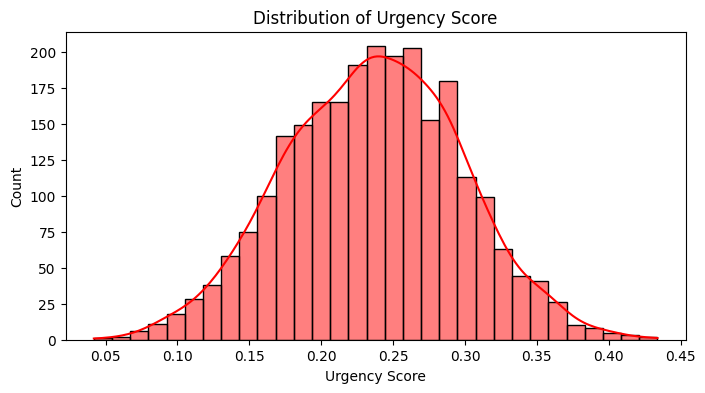

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(df['urgency_score'], kde=True, color='red')
plt.title('Distribution of Urgency Score')
plt.xlabel('Urgency Score')
plt.ylabel('Count')
plt.show()

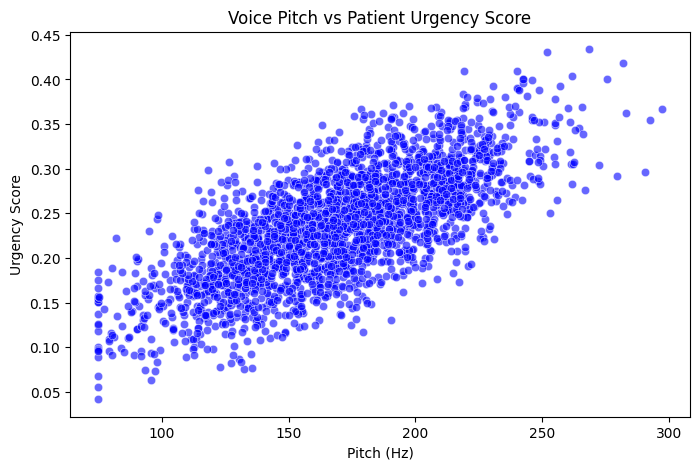

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pitch_hz', y='urgency_score', alpha=0.6, color='blue')
plt.title('Voice Pitch vs Patient Urgency Score')
plt.xlabel('Pitch (Hz)')
plt.ylabel('Urgency Score')
plt.show()

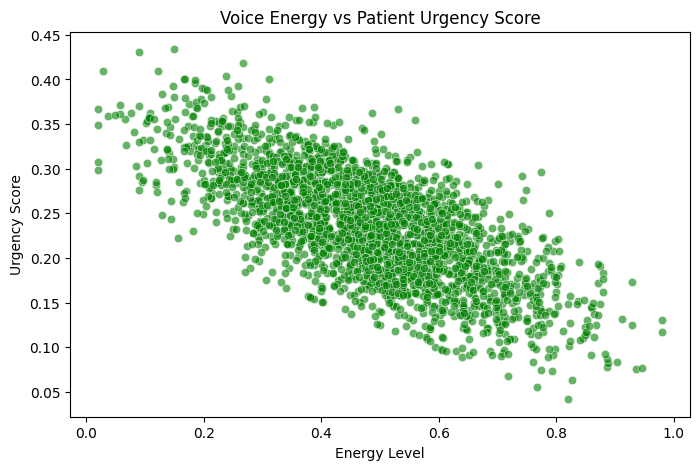

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='energy', y='urgency_score', alpha=0.6, color='green')
plt.title('Voice Energy vs Patient Urgency Score')
plt.xlabel('Energy Level')
plt.ylabel('Urgency Score')
plt.show()

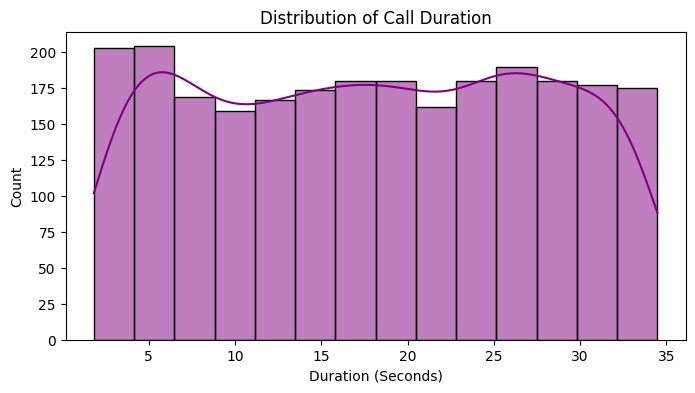

In [15]:
plt.figure(figsize=(8, 4))
sns.histplot(df['duration_sec'], kde=True, color='purple')
plt.title('Distribution of Call Duration')
plt.xlabel('Duration (Seconds)')
plt.ylabel('Count')
plt.show()

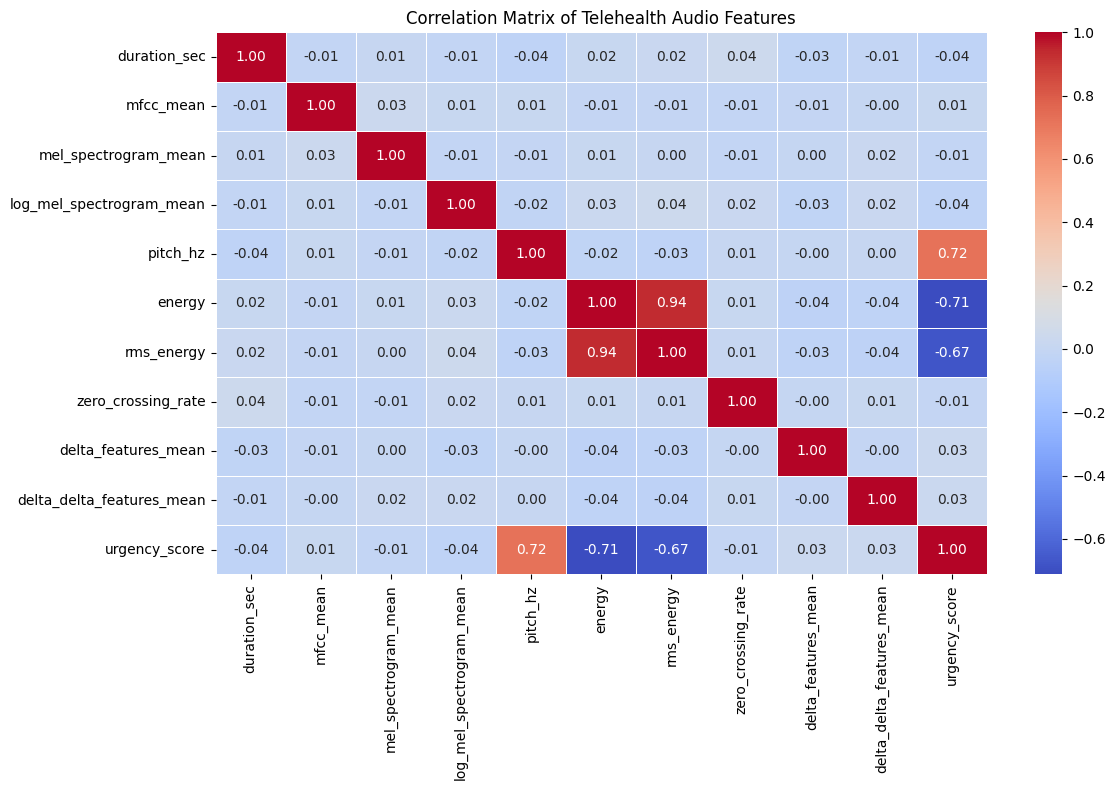

In [16]:
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Telehealth Audio Features')
plt.tight_layout()
plt.show()

In [17]:
df.columns

Index(['duration_sec', 'mfcc_mean', 'mel_spectrogram_mean',
       'log_mel_spectrogram_mean', 'pitch_hz', 'energy', 'rms_energy',
       'zero_crossing_rate', 'delta_features_mean',
       'delta_delta_features_mean', 'transcript_text', 'urgency_score'],
      dtype='object')

In [18]:
df.head()

,duration_sec,mfcc_mean,mel_spectrogram_mean,log_mel_spectrogram_mean,pitch_hz,energy,rms_energy,zero_crossing_rate,delta_features_mean,delta_delta_features_mean,transcript_text,urgency_score
0,22.71,-101.559,151.356,-7.479,166.49,0.3602,0.2399,0.1244,-2.925,-1.551,Participants discussed evaluation metrics befo...,0.264398
1,9.01,-78.185,92.299,-6.230,205.48,0.4867,0.4312,0.0818,3.292,-0.948,The discussion scheduled the final roadmap to ...,0.275348
2,28.19,-90.366,215.363,-1.969,75.00,0.3829,0.2852,0.0316,1.473,-2.634,The discussion presented the final roadmap bef...,0.155495
3,16.63,-77.621,173.317,-7.079,145.05,0.5582,0.4695,0.1090,0.972,0.198,"In this client call, the speaker explained noi...",0.188700
4,24.19,-40.735,218.823,-4.622,169.27,0.5205,0.3769,0.0827,1.119,-0.605,The discussion confirmed customer feedback for...,0.225783


In [19]:
df.drop("transcript_text",axis=1,inplace=True)
df.head()

,duration_sec,mfcc_mean,mel_spectrogram_mean,log_mel_spectrogram_mean,pitch_hz,energy,rms_energy,zero_crossing_rate,delta_features_mean,delta_delta_features_mean,urgency_score
0,22.71,-101.559,151.356,-7.479,166.49,0.3602,0.2399,0.1244,-2.925,-1.551,0.264398
1,9.01,-78.185,92.299,-6.230,205.48,0.4867,0.4312,0.0818,3.292,-0.948,0.275348
2,28.19,-90.366,215.363,-1.969,75.00,0.3829,0.2852,0.0316,1.473,-2.634,0.155495
3,16.63,-77.621,173.317,-7.079,145.05,0.5582,0.4695,0.1090,0.972,0.198,0.188700
4,24.19,-40.735,218.823,-4.622,169.27,0.5205,0.3769,0.0827,1.119,-0.605,0.225783


In [20]:
scaler = StandardScaler()

col = df.columns[0:10]

df[col] = scaler.fit_transform(df[col])
df.head()

,duration_sec,mfcc_mean,mel_spectrogram_mean,log_mel_spectrogram_mean,pitch_hz,energy,rms_energy,zero_crossing_rate,delta_features_mean,delta_delta_features_mean,urgency_score
0,0.491839,0.156404,0.329891,-1.620289,-0.068191,-0.732442,-1.013812,1.355848,-1.427297,-0.919890,0.264398
1,-0.939359,0.682648,-0.536332,-1.190496,0.956434,0.045523,0.385197,-0.092417,1.602156,-0.554620,0.275348
2,1.064318,0.408404,1.268718,0.275755,-2.472471,-0.592839,-0.682525,-1.799058,0.715784,-1.575923,0.155495
3,-0.143320,0.695346,0.652006,-1.482646,-0.631616,0.485242,0.665291,0.832297,0.471654,0.139576,0.188700
4,0.646450,1.525801,1.319468,-0.637168,0.004865,0.253390,-0.011908,-0.061820,0.543285,-0.346846,0.225783


In [21]:
X = df.drop("urgency_score",axis=1)
y = df["urgency_score"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss="mean_squared_error", optimizer="adam", metrics=["r2_score"])

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,737 (49.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [25]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5)
    ],
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0164 - r2_score: -3.4057 - val_loss: 0.0209 - val_r2_score: -4.6826
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0064 - r2_score: -0.7312 - val_loss: 0.0075 - val_r2_score: -1.0438
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0048 - r2_score: -0.2834 - val_loss: 0.0033 - val_r2_score: 0.0926
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - r2_score: 0.0867 - val_loss: 0.0020 - val_r2_score: 0.4580
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 - r2_score: 0.2289 - val_loss: 9.7262e-04 - val_r2_score: 0.7359
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025 - r2_score: 0.3303 - val_loss: 6.8510e-04 - val_r2_score: 0.8140
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 - r2_score: 0.3768 - val_loss: 6.3732e-04 - val_r2_score: 0.8270
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0020 - r2_score: 0.4632 - val_loss: 6.14

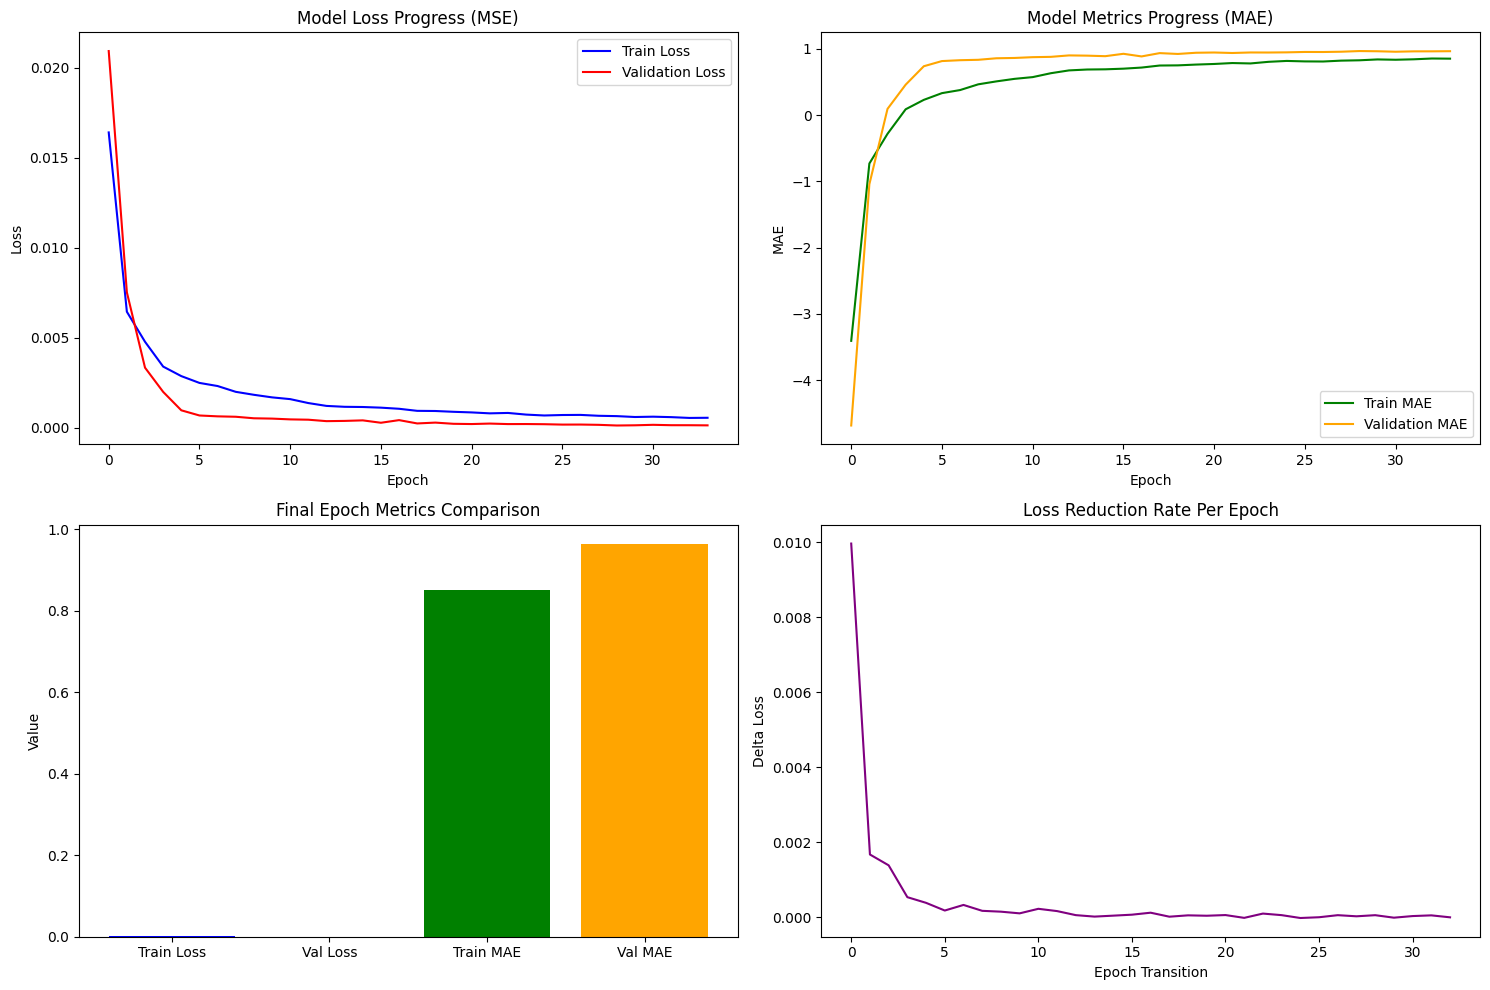

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(history.history['loss'], color='blue')
axes[0, 0].plot(history.history['val_loss'], color='red')
axes[0, 0].set_title('Model Loss Progress (MSE)')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend(['Train Loss', 'Validation Loss'])

axes[0, 1].plot(history.history['r2_score'], color='green')
axes[0, 1].plot(history.history['val_r2_score'], color='orange')
axes[0, 1].set_title('Model Metrics Progress (MAE)')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend(['Train MAE', 'Validation MAE'])

final_metrics = [history.history['loss'][-1], history.history['val_loss'][-1], history.history['r2_score'][-1], history.history['val_r2_score'][-1]]
metric_labels = ['Train Loss', 'Val Loss', 'Train MAE', 'Val MAE']
axes[1, 0].bar(metric_labels, final_metrics, color=['blue', 'red', 'green', 'orange'])
axes[1, 0].set_title('Final Epoch Metrics Comparison')
axes[1, 0].set_ylabel('Value')

loss_diff = [history.history['loss'][i] - history.history['loss'][i+1] for i in range(len(history.history['loss'])-1)]
axes[1, 1].plot(loss_diff, color='purple')
axes[1, 1].set_title('Loss Reduction Rate Per Epoch')
axes[1, 1].set_ylabel('Delta Loss')
axes[1, 1].set_xlabel('Epoch Transition')

plt.tight_layout()
plt.show()

In [27]:
model.save("model.h5")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']